# **Ground Detection – Klassifikation der Fahrbahnoberfläche**

Dieses Notebook klassifiziert die **Bodenbeschaffenheit der Fahrbahn** auf den Frames,
die zuvor im Notebook [`pre_processing.ipynb`](./pre_processing.ipynb) extrahiert wurden.

**Datengrundlage:** Die in `dataset/frames/<videoname>/original/` gespeicherten Einzelbilder
(1 Bild pro Sekunde) der frontal am Fahrradlenker montierten DJI-Kamera.

**Ziel:** Für den *Bikeability-Score* ist die Fahrbahnoberfläche $O_{surf}$ ein relevantes
Merkmal (vgl. [`README.md`](../README.md)). Glatter **Asphalt** ist fahrradfreundlich, während
**Kopfsteinpflaster**, **Schotter/Kies** oder ein **Erd-/Feldweg** den Fahrkomfort und damit
die Bikeability senken. Wir erkennen je Frame, ob der Boden z. B. asphaltiert ist, Kies bzw.
Schotter hat, aus Erde besteht, Kopfsteinpflaster ist usw.

**Methodik – zwei vortrainierte Modelle in Reihe (Zero-Shot, ohne eigenes Training):**

1. **Semantische Segmentierung** mit
   [**SegFormer**](https://huggingface.co/nvidia/segformer-b5-finetuned-cityscapes-1024-1024)
   (auf *Cityscapes* feinjustiert, vgl. [`cityscapes.ipynb`](../cityscapes.ipynb)). Damit bestimmen
   wir **pixelgenau**, welche Bildbereiche zur **Straße** (`road`) gehören. So lösen wir die
   Fahrbahn unabhängig von ihrer Lage im Bild zuverlässig heraus – statt eines starren Bildausschnitts.
2. **Zuschnitt auf die Straße:** Alle Nicht-Straßen-Pixel werden ausmaskiert und das Bild auf die
   Bounding-Box der Straßen-Maske zugeschnitten. Nur dieser **Straßenausschnitt** gelangt ins CLIP-Modell.
3. **Oberflächen-Klassifikation** mit
   [**CLIP**](https://github.com/openai/CLIP) (Contrastive Language–Image Pre-training): Der
   Straßenausschnitt wird mit textuellen Beschreibungen der Oberflächentypen verglichen und die
   ähnlichste Klasse gewählt.

**Ablauf des Notebooks:**

1. **Setup & Modelle laden** – SegFormer (Segmentierung) und CLIP (Oberfläche) vorbereiten.
2. **Konfiguration** – Pfade, Oberflächen-Klassen und Straßen-Klasse definieren.
3. **Textprompts** – CLIP-Text-Embeddings der Oberflächen-Prompts berechnen.
4. **Segmentierung & Straßen-Zuschnitt** – Straße erkennen, maskieren, zuschneiden.
5. **Einzelbild-Test** – Segmentierung, Zuschnitt und Klassifikation an einem Beispielframe visualisieren.
6. **Batch-Klassifikation** – Alle Frames verarbeiten, annotierte Bilder speichern.
7. **Auswertung** – Oberflächen-Verteilung je Video für die Bikeability-Analyse aggregieren.


## 1. Setup & Imports

`pip install torch transformers pillow opencv-python numpy matplotlib`

Beim ersten Aufruf lädt `transformers` automatisch die Modellgewichte herunter und legt sie im
lokalen Cache ab:
- **CLIP** (`openai/clip-vit-base-patch32`, ca. 600 MB) für die Oberflächen-Klassifikation,
- **SegFormer** (`nvidia/segformer-b5-finetuned-cityscapes-1024-1024`, ca. 350 MB) für die
  semantische Segmentierung der Straße.

Ist eine CUDA-fähige GPU vorhanden, wird sie automatisch genutzt.


In [1]:
from __future__ import annotations

from collections import Counter
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image
from transformers import (
    CLIPModel,
    CLIPProcessor,
    SegformerForSemanticSegmentation,
    SegformerImageProcessor,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch-Version: {torch.__version__}")
print(f"Rechengerät (Device): {DEVICE}")


PyTorch-Version: 2.6.0+cpu
Rechengerät (Device): cpu


## 2. Konfiguration

Das Notebook liegt im Ordner `research/`, die Daten daher relativ unter `../dataset/`.
Wir verarbeiten die `original`-Frames und schreiben annotierte Bilder nach
`dataset/frames/<videoname>/ground/`.

**Straßen-Erkennung:** Statt eines starren Bildausschnitts bestimmen wir die Fahrbahn per
SegFormer-Segmentierung. In den 19 *Cityscapes*-Klassen hat die Straße die Train-ID `0` (`road`).
Nur Frames mit ausreichend großer Straßenfläche (`MIN_ROAD_RATIO`) werden klassifiziert.

**Oberflächen-Klassen:** Für jede Klasse definieren wir mehrere englische Textbeschreibungen
(*Prompts*), da CLIP auf englischsprachigen Bild-Text-Paaren trainiert wurde. Mehrere Prompts
pro Klasse erhöhen die Robustheit. Zusätzlich ordnen wir jeder Oberfläche einen
**Komfort-/Qualitätswert** $\in [0, 1]$ zu (1 = ideal fahrradfreundlich), der als
Feature $O_{surf}$ in den Bikeability-Score einfließen kann.


In [8]:
# Pfade (Notebook liegt in research/, daher eine Ebene höher)
FRAMES_DIR = Path("../dataset/frames")
SOURCE_SUBDIR = "original"   # Eingangs-Frames
OUTPUT_SUBDIR = "cropped_ground"     # Ziel für annotierte Bilder

# Modelle
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
SEG_MODEL_NAME = "nvidia/segformer-b5-finetuned-cityscapes-1024-1024"
JPEG_QUALITY = 95
OVERWRITE = False

# Straßen-Segmentierung: Cityscapes-Train-ID der Klasse 'road' ist 0.
ROAD_CLASS_ID = 0
# Mindestanteil an Straßen-Pixeln, damit ein Frame klassifiziert wird (sonst übersprungen).
MIN_ROAD_RATIO = 0.02

# Oberflächen-Klassen: Name → (englische CLIP-Prompts, Komfort/Qualität 0..1)
SURFACE_CLASSES: dict[str, dict] = {
    "Asphalt/Beton": {
        "prompts": [
            "a photo of a smooth asphalt road surface",
            "a tarmac bike path",
            "black asphalt pavement",
            "a photo of a concrete road surface",
            "a smooth concrete pavement",
        ],
        "quality": 1.00,
    },
    "Pflaster/Kopfsteinpflaster": {
        "prompts": [
            "a photo of a road paved with rectangular paving stones",
            "interlocking concrete block paving",
            "a brick paved path",
            "a photo of a cobblestone street",
            "a rough cobbled road with round stones",
            "an old cobblestone pavement",
        ],
        "quality": 0.45,
    },
    "Schotter/Kies": {
        "prompts": [
            "a photo of a gravel road",
            "a path covered with loose gravel and small stones",
            "a crushed stone gravel track",
        ],
        "quality": 0.25,
    },
    "Erde/Feldweg": {
        "prompts": [
            "a photo of a dirt road made of bare soil",
            "an unpaved earth field path",
            "a muddy dirt track",
        ],
        "quality": 0.20,
    },
}

# Alle Videos mit vorhandenem original-Ordner finden
video_dirs = sorted(
    p.parent for p in FRAMES_DIR.glob(f"*/{SOURCE_SUBDIR}") if p.is_dir()
)

print(f"Gefundene Videos in '{FRAMES_DIR}/': {len(video_dirs)}")
for d in video_dirs:
    n = len(list((d / SOURCE_SUBDIR).glob("*.jpg")))
    print(f"  - {d.name}: {n} Frames")

if not video_dirs:
    print("\nKeine Frames gefunden. Bitte zuerst 'pre_processing.ipynb' ausführen.")


Gefundene Videos in '..\dataset\frames/': 3
  - beispiel_dji_0390: 4 Frames
  - DJI_0375: 354 Frames
  - DJI_0376: 409 Frames


## 3. Modelle laden & Textprompts vorbereiten

Wir laden beide vortrainierten Modelle:
- **SegFormer** segmentiert das Bild semantisch und liefert die Straßen-Maske.
- **CLIP** klassifiziert anschließend die Oberfläche des Straßenausschnitts.

Außerdem berechnen wir **einmalig** die CLIP-Text-Embeddings aller Oberflächen-Prompts. Diese
werden normalisiert, sodass die spätere Ähnlichkeit zum Bild über das Skalarprodukt
(Kosinus-Ähnlichkeit) berechnet werden kann.


In [9]:
# CLIP (Oberflächen-Klassifikation)
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(DEVICE).eval()
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)

# SegFormer (Straßen-Segmentierung, Cityscapes)
seg_processor = SegformerImageProcessor.from_pretrained(SEG_MODEL_NAME)
seg_model = SegformerForSemanticSegmentation.from_pretrained(SEG_MODEL_NAME).to(DEVICE).eval()

# Flache Liste aller Prompts + Zuordnung Prompt-Index → Klassenname
prompts: list[str] = []
prompt_to_class: list[str] = []
for cls_name, cfg in SURFACE_CLASSES.items():
    for p in cfg["prompts"]:
        prompts.append(p)
        prompt_to_class.append(cls_name)

# Text-Embeddings einmalig berechnen und normalisieren
with torch.no_grad():
    text_inputs = clip_processor(text=prompts, return_tensors="pt", padding=True).to(DEVICE)
    text_features = clip_model.get_text_features(**text_inputs)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

CLASS_NAMES = list(SURFACE_CLASSES)
print(f"CLIP-Modell geladen:      {CLIP_MODEL_NAME}")
print(f"SegFormer-Modell geladen: {SEG_MODEL_NAME}")
print(f"Klassen ({len(CLASS_NAMES)}): {CLASS_NAMES}")
print(f"Anzahl Textprompts: {len(prompts)}")


CLIP-Modell geladen:      openai/clip-vit-base-patch32
SegFormer-Modell geladen: nvidia/segformer-b5-finetuned-cityscapes-1024-1024
Klassen (4): ['Asphalt/Beton', 'Pflaster/Kopfsteinpflaster', 'Schotter/Kies', 'Erde/Feldweg']
Anzahl Textprompts: 17


## 4. Segmentierung, Straßen-Zuschnitt & Klassifikation

Statt eines starren Bildausschnitts bestimmen wir die Fahrbahn **pixelgenau** per Segmentierung:

1. `segment_frame` lässt SegFormer das Bild segmentieren und liefert eine Klassen-ID-Karte
   (eine Klasse pro Pixel).
2. `extract_road` bildet aus der Klasse `road` (ID 0) eine binäre Maske, **maskiert alle
   Nicht-Straßen-Pixel aus** (auf Schwarz) und schneidet das Bild auf die Bounding-Box der
   Straßen-Maske zu. Frames mit zu wenig Straßenfläche (`MIN_ROAD_RATIO`) liefern `None`.
3. `classify_surface` berechnet das (normalisierte) CLIP-Bild-Embedding des Straßenausschnitts,
   vergleicht es mit allen Text-Embeddings, aggregiert die Prompt-Ähnlichkeiten je Klasse
   (Maximum) und wandelt die Werte per *Softmax* in Wahrscheinlichkeiten um.


In [10]:
def segment_frame(image_bgr: np.ndarray) -> np.ndarray:
    """Segmentiert ein BGR-Bild mit SegFormer und liefert eine (H, W) Klassen-ID-Karte."""
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(rgb)

    with torch.no_grad():
        inputs = seg_processor(images=pil_img, return_tensors="pt").to(DEVICE)
        logits = seg_model(**inputs).logits  # [1, 19, H/4, W/4]
        # Niedrig aufgelöste Logits auf Originalgröße hochskalieren (size = (H, W)).
        upsampled = F.interpolate(
            logits, size=pil_img.size[::-1], mode="bilinear", align_corners=False
        )

    return upsampled.argmax(dim=1)[0].cpu().numpy()


def extract_road(image_bgr: np.ndarray, seg_map: np.ndarray) -> dict | None:
    """Maskiert alle Nicht-Straßen-Pixel aus und schneidet auf die Straßen-Bounding-Box zu.

    Rückgabe: Dict mit 'crop' (BGR-Ausschnitt, nur Straße), 'mask' (bool-Maske) und
    'bbox' (y1, y2, x1, x2) – oder None, wenn zu wenig Straße erkannt wurde.
    """
    mask = seg_map == ROAD_CLASS_ID
    h, w = seg_map.shape
    if mask.sum() < MIN_ROAD_RATIO * h * w:
        return None

    ys, xs = np.where(mask)
    y1, y2 = int(ys.min()), int(ys.max())
    x1, x2 = int(xs.min()), int(xs.max())

    # Nur Straßen-Pixel behalten, Rest auf Schwarz; dann auf Bounding-Box zuschneiden.
    masked = image_bgr.copy()
    masked[~mask] = 0
    road_crop = masked[y1 : y2 + 1, x1 : x2 + 1]

    return {"crop": road_crop, "mask": mask, "bbox": (y1, y2, x1, x2)}


def classify_surface(road_bgr: np.ndarray) -> dict[str, float]:
    """Klassifiziert die Oberfläche eines Straßenausschnitts per CLIP (Zero-Shot).

    Rückgabe: Dict {Klassenname: Wahrscheinlichkeit}, absteigend sortiert.
    """
    rgb = cv2.cvtColor(road_bgr, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(rgb)

    with torch.no_grad():
        img_inputs = clip_processor(images=pil_img, return_tensors="pt").to(DEVICE)
        img_features = clip_model.get_image_features(**img_inputs)
        img_features = img_features / img_features.norm(dim=-1, keepdim=True)
        # Kosinus-Ähnlichkeit zu jedem Prompt
        sims = (img_features @ text_features.T).squeeze(0)  # [n_prompts]

    # Pro Klasse die stärkste Prompt-Ähnlichkeit verwenden
    class_sims = torch.tensor(
        [sims[[i for i, c in enumerate(prompt_to_class) if c == cls]].max()
         for cls in CLASS_NAMES]
    )
    # Softmax (Temperatur 100 = CLIP-Logit-Skala) → Wahrscheinlichkeiten
    probs = torch.softmax(class_sims * 100.0, dim=0)

    result = {cls: float(p) for cls, p in zip(CLASS_NAMES, probs)}
    return dict(sorted(result.items(), key=lambda kv: kv[1], reverse=True))


print("Segmentierungs-, Zuschnitt- und Klassifikationsfunktionen definiert.")


Segmentierungs-, Zuschnitt- und Klassifikationsfunktionen definiert.


## 5. Einzelbild-Test

Wir testen die komplette Pipeline an einem Beispielframe: Links das Originalbild mit
**grün eingefärbter Straßen-Maske** und der Bounding-Box, rechts der ausmaskierte
Straßenausschnitt samt erkannter Oberfläche und den Wahrscheinlichkeiten aller Klassen.


Beispielframe: ..\dataset\frames\beispiel_dji_0390\original\frame_00227.jpg
Erkannte Oberfläche: Asphalt/Beton (74.8%)
  Asphalt/Beton      74.8%
  Pflaster/Kopfsteinpflaster 19.8%
  Schotter/Kies       4.8%
  Erde/Feldweg        0.6%


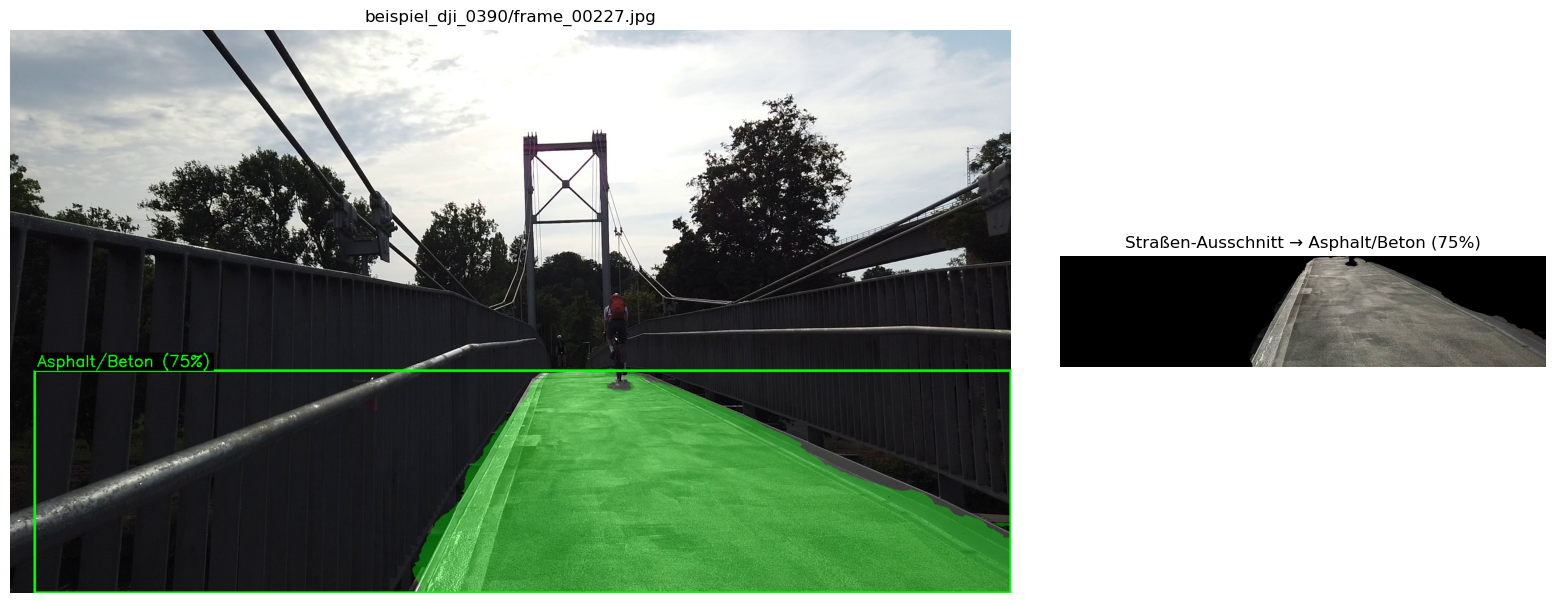

In [11]:
def annotate_frame(
    image_bgr: np.ndarray, road: dict, label: str, prob: float
) -> np.ndarray:
    """Färbt die Straßen-Maske grün ein, zeichnet Bounding-Box und Label auf das Bild."""
    out = image_bgr.copy()
    mask = road["mask"]
    y1, y2, x1, x2 = road["bbox"]

    # Straßen-Maske halbtransparent grün einfärben
    overlay = out.copy()
    overlay[mask] = (0, 255, 0)
    out = cv2.addWeighted(overlay, 0.35, out, 0.65, 0)

    cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 3)
    text = f"{label} ({prob * 100:.0f}%)"
    font, scale, thick = cv2.FONT_HERSHEY_SIMPLEX, 1.0, 2
    (tw, th), _ = cv2.getTextSize(text, font, scale, thick)
    ty = max(y1, th + 12)
    cv2.rectangle(out, (x1, ty - th - 12), (x1 + tw + 10, ty), (0, 0, 0), -1)
    cv2.putText(out, text, (x1 + 5, ty - 8), font, scale, (0, 255, 0), thick)
    return out


# Erstes verfügbares Frame als Beispiel wählen (mittleres Frame)
sample_frame = None
for d in video_dirs:
    frames = sorted((d / SOURCE_SUBDIR).glob("*.jpg"))
    if frames:
        sample_frame = frames[len(frames) // 2]
        break

if sample_frame is None:
    print("Kein Beispielframe gefunden.")
else:
    print(f"Beispielframe: {sample_frame}")
    image = cv2.imread(str(sample_frame))

    seg_map = segment_frame(image)
    road = extract_road(image, seg_map)

    if road is None:
        print("Keine (ausreichend große) Straße im Frame erkannt.")
    else:
        probs = classify_surface(road["crop"])
        top_label, top_prob = next(iter(probs.items()))
        print(f"Erkannte Oberfläche: {top_label} ({top_prob * 100:.1f}%)")
        for cls, p in probs.items():
            print(f"  {cls:<18}{p * 100:5.1f}%")

        annotated = annotate_frame(image, road, top_label, top_prob)

        fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                                 gridspec_kw={"width_ratios": [2.2, 1]})
        axes[0].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f"{sample_frame.parent.parent.name}/{sample_frame.name}")
        axes[0].axis("off")

        axes[1].imshow(cv2.cvtColor(road["crop"], cv2.COLOR_BGR2RGB))
        axes[1].set_title(f"Straßen-Ausschnitt → {top_label} ({top_prob * 100:.0f}%)")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()


## 6. Batch-Klassifikation über alle Frames

Die folgende Funktion verarbeitet alle `original`-Frames eines Videos durch die komplette
Pipeline (Segmentierung → Straßen-Zuschnitt → CLIP-Klassifikation), speichert die annotierten
Bilder nach `dataset/frames/<videoname>/ground/` und liefert pro Frame die erkannte Klasse
samt Wahrscheinlichkeit und Qualitätswert zurück. Frames ohne ausreichend erkannte Straße
werden gezählt und übersprungen.


In [12]:
def classify_video_frames(
    video_dir: Path,
    overwrite: bool = False,
) -> list[dict]:
    """Verarbeitet alle original-Frames eines Videos durch die komplette Pipeline.

    Segmentierung (SegFormer) → Straßen-Zuschnitt → CLIP-Oberflächen-Klassifikation.
    Annotierte Bilder werden nach <video_dir>/ground/ geschrieben.
    Rückgabe: Liste von Dicts mit Frame-Name, Klasse, Wahrscheinlichkeit und Qualität.
    """
    src_dir = video_dir / SOURCE_SUBDIR
    out_dir = video_dir / OUTPUT_SUBDIR
    out_dir.mkdir(parents=True, exist_ok=True)

    frame_paths = sorted(src_dir.glob("*.jpg"))
    records: list[dict] = []
    skipped = 0

    print(f"▶ {video_dir.name}: {len(frame_paths)} Frames")

    for frame_path in frame_paths:
        out_path = out_dir / frame_path.name
        image = cv2.imread(str(frame_path))
        if image is None:
            continue

        seg_map = segment_frame(image)
        road = extract_road(image, seg_map)
        if road is None:
            skipped += 1
            continue

        probs = classify_surface(road["crop"])
        top_label, top_prob = next(iter(probs.items()))

        if overwrite or not out_path.exists():
            annotated = annotate_frame(image, road, top_label, top_prob)
            cv2.imwrite(str(out_path), annotated,
                        [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY])

        records.append({
            "video": video_dir.name,
            "frame": frame_path.name,
            "surface": top_label,
            "confidence": round(top_prob, 4),
            "quality": SURFACE_CLASSES[top_label]["quality"],
        })

    msg = f"  ✅ annotierte Bilder gespeichert in '{out_dir}'"
    if skipped:
        msg += f" (übersprungen ohne Straße: {skipped})"
    print(msg)
    return records


all_records: list[dict] = []
for video_dir in video_dirs:
    all_records.extend(classify_video_frames(video_dir, overwrite=OVERWRITE))

print(f"\nFertig. Insgesamt {len(all_records)} Frames klassifiziert.")


▶ beispiel_dji_0390: 4 Frames
  ✅ annotierte Bilder gespeichert in '..\dataset\frames\beispiel_dji_0390\cropped_ground'
▶ DJI_0375: 354 Frames


KeyboardInterrupt: 

## 7. Auswertung für die Bikeability-Analyse

Wir aggregieren die Oberflächen-Klassifikationen je Video: die Häufigkeit jeder Oberflächen-Klasse
sowie den **durchschnittlichen Oberflächen-Qualitätswert** $\bar{O}_{surf} \in [0, 1]$. Ein hoher
Wert (viel Asphalt/Beton) wirkt sich positiv auf den Bikeability-Score aus, ein niedriger Wert
(Kopfsteinpflaster, Schotter, Erde) negativ.


In [10]:
# Aggregation je Video: Häufigkeit pro Klasse + mittlerer Qualitätswert
summary: dict[str, dict] = {}
for rec in all_records:
    v = rec["video"]
    agg = summary.setdefault(
        v, {"frames": 0, "quality_sum": 0.0, **{c: 0 for c in CLASS_NAMES}}
    )
    agg["frames"] += 1
    agg["quality_sum"] += rec["quality"]
    agg[rec["surface"]] += 1

# Ausgabe als Tabelle
header = f"{'Video':<24}{'Frames':>7}"
for cls in CLASS_NAMES:
    header += f"{cls[:12]:>13}"
header += f"{'Ø Qualität':>12}"
print(header)

for v, agg in summary.items():
    row = f"{v:<24}{agg['frames']:>7}"
    for cls in CLASS_NAMES:
        row += f"{agg[cls]:>13}"
    mean_quality = agg["quality_sum"] / agg["frames"] if agg["frames"] else 0
    row += f"{mean_quality:>12.2f}"
    print(row)


Video                    Frames Asphalt/Beto Pflaster/Kop Schotter/Kie Erde/Feldweg  Ø Qualität
beispiel_dji_0390             4            4            0            0            0        1.00
DJI_0375                    354          229           39           81            5        0.76
DJI_0376                    409          224          182            2            1        0.75


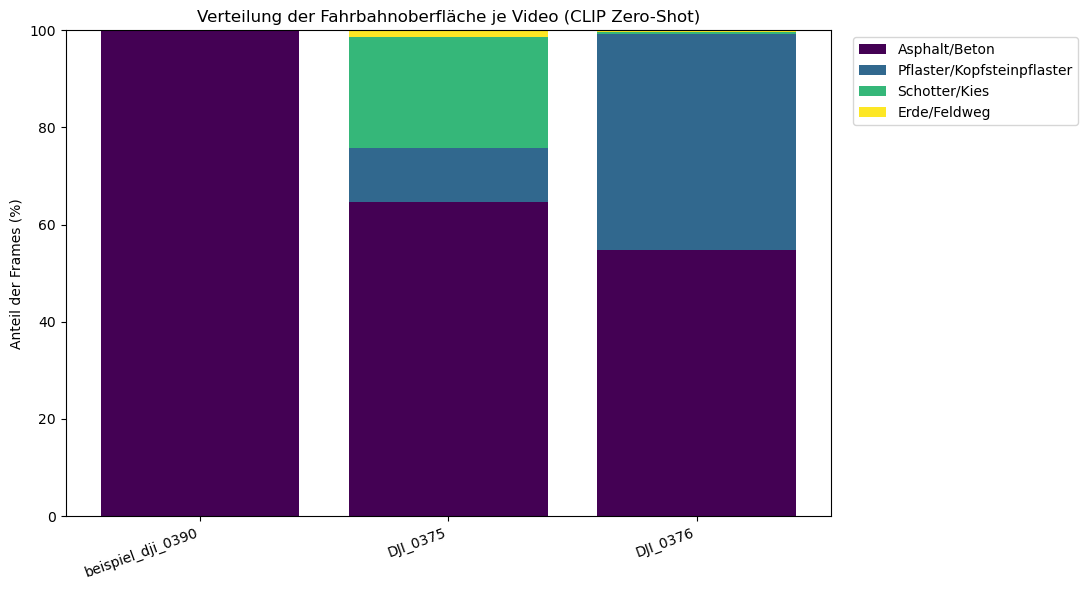

In [12]:
# Gestapeltes Balkendiagramm: Anteil der Oberflächen-Klassen je Video
if summary:
    videos = list(summary)
    x = np.arange(len(videos))
    cmap = plt.get_cmap("viridis", len(CLASS_NAMES))

    plt.figure(figsize=(11, 6))
    bottom = np.zeros(len(videos))
    for i, cls in enumerate(CLASS_NAMES):
        # Anteil (in %) der Klasse je Video
        shares = [summary[v][cls] / summary[v]["frames"] * 100 for v in videos]
        plt.bar(x, shares, bottom=bottom, label=cls, color=cmap(i))
        bottom += np.array(shares)

    plt.xticks(x, videos, rotation=20, ha="right")
    plt.ylabel("Anteil der Frames (%)")
    plt.title("Verteilung der Fahrbahnoberfläche je Video (CLIP Zero-Shot)")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Keine Auswertungsdaten vorhanden.")
